In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.datasets import make_blobs
import torch
from torch import nn
import torch.nn as nn
from sklearn.model_selection import train_test_split

In [58]:
X_blob,y_blob = make_blobs(n_samples=1000,n_features = 2,centers = 4,cluster_std=1.5,random_state=42)

In [59]:
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

In [60]:
X_blob_train,X_blob_test,y_blob_train,y_blob_test = train_test_split(X_blob,y_blob,test_size=0.2,random_state=42)

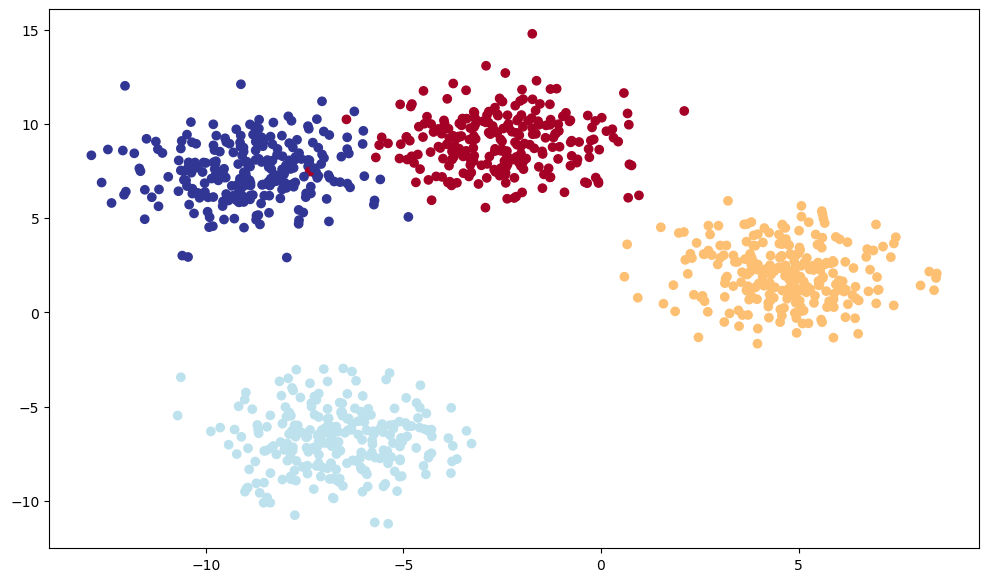

In [61]:
plt.figure(figsize=(12,7))
plt.scatter(x=X_blob[:,0],y=X_blob[:,1],c=y_blob,cmap = plt.cm.RdYlBu)

In [62]:
X_blob_train.shape,X_blob_test.shape,y_blob_train.shape,y_blob_test.shape

(torch.Size([800, 2]),
 torch.Size([200, 2]),
 torch.Size([800]),
 torch.Size([200]))

In [63]:
class BlobModule(nn.Module):
    def __init__(self,input_features,output_features,hidden_units = 8):
        super().__init__()
        self.linear_layers = nn.Sequential(
            nn.Linear(in_features=input_features,out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units,out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units,out_features=output_features)
        )
        
    def forward(self,x:torch.Tensor) -> torch.Tensor:
        return self.linear_layers(x)
    
    
model_0 = BlobModule(input_features=2,output_features=4,hidden_units=8)
model_0

BlobModule(
  (linear_layers): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [64]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_0.parameters(),lr = 0.1)

In [65]:
model_0.eval()
with torch.inference_mode():
    y_logits = model_0(X_blob_test)
y_logits[:10]

tensor([[ 0.5084,  0.1430, -0.6593,  0.9157],
        [-1.0699,  0.2205, -0.1064,  0.1042],
        [-0.0644,  0.3630, -0.5015,  0.7949],
        [ 0.5790, -0.0330, -0.6098,  0.7012],
        [-0.4585,  0.0316, -0.6992,  0.8058],
        [-1.2995,  0.2683, -0.0366,  0.0399],
        [ 0.1840,  0.1993, -0.8468,  0.9903],
        [-0.6015,  0.0795, -0.5355,  0.6091],
        [-0.1140,  0.2596, -0.3652,  0.7469],
        [-0.5369,  0.0607, -0.5906,  0.6734]])

In [66]:
y_blob_test[:5]

tensor([1, 3, 2, 1, 0])

In [67]:
y_pred_probs = torch.softmax(y_logits,dim=1)
print(y_logits[:5])
print(y_pred_probs[:5])

tensor([[ 0.5084,  0.1430, -0.6593,  0.9157],
        [-1.0699,  0.2205, -0.1064,  0.1042],
        [-0.0644,  0.3630, -0.5015,  0.7949],
        [ 0.5790, -0.0330, -0.6098,  0.7012],
        [-0.4585,  0.0316, -0.6992,  0.8058]])
tensor([[0.2851, 0.1978, 0.0887, 0.4284],
        [0.0953, 0.3464, 0.2498, 0.3084],
        [0.1805, 0.2767, 0.1166, 0.4262],
        [0.3359, 0.1822, 0.1023, 0.3796],
        [0.1437, 0.2346, 0.1130, 0.5088]])


In [68]:
torch.sum(y_pred_probs[2])

tensor(1.0000)

In [69]:
y_predss = torch.argmax(y_pred_probs,dim=1)
y_predss

tensor([3, 1, 3, 3, 3, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 3, 1, 1, 3, 3, 3, 3,
        3, 3, 1, 3, 3, 3, 1, 3, 3, 1, 3, 3, 3, 1, 3, 3, 3, 1, 1, 3, 3, 3, 3, 3,
        3, 1, 3, 3, 3, 3, 1, 3, 3, 3, 1, 3, 3, 3, 1, 3, 3, 3, 3, 1, 1, 3, 3, 1,
        1, 1, 3, 1, 1, 1, 3, 3, 3, 3, 3, 3, 1, 1, 3, 1, 1, 3, 1, 1, 3, 1, 1, 1,
        3, 3, 1, 3, 3, 3, 3, 3, 3, 1, 3, 3, 1, 3, 3, 3, 3, 3, 3, 1, 3, 3, 3, 3,
        3, 1, 3, 3, 3, 3, 3, 3, 3, 1, 3, 3, 3, 3, 3, 1, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 3, 1, 3, 3, 3, 3, 1, 3, 3, 3, 1, 1, 3, 3, 3, 3, 1, 3, 3, 1, 3, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 1, 3, 3, 1, 3, 3, 3])

In [70]:
y_blob_test

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0, 0, 1, 0, 0, 0, 3, 3, 2, 3, 3, 3, 0, 1, 2,
        2, 2, 3, 0, 1, 0, 3, 1, 1, 3, 1, 2, 1, 3, 0, 2, 0, 3, 3, 2, 0, 3, 1, 1,
        0, 3, 1, 0, 1, 1, 3, 2, 1, 1, 3, 2, 2, 0, 3, 2, 2, 0, 0, 3, 3, 0, 0, 3,
        3, 3, 2, 3, 3, 3, 3, 1, 0, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3,
        1, 0, 3, 2, 0, 0, 3, 0, 2, 3, 1, 0, 3, 2, 1, 1, 0, 2, 2, 3, 0, 0, 1, 2,
        2, 3, 0, 1, 2, 0, 0, 0, 2, 3, 1, 2, 3, 2, 0, 3, 0, 0, 1, 1, 1, 0, 2, 2,
        2, 2, 0, 3, 3, 2, 2, 1, 3, 2, 0, 0, 3, 3, 2, 1, 2, 0, 3, 2, 0, 3, 2, 0,
        2, 2, 2, 0, 3, 1, 1, 1, 1, 1, 3, 1, 0, 2, 2, 1, 2, 2, 0, 1, 2, 2, 0, 0,
        1, 3, 2, 0, 3, 1, 2, 1])

In [71]:
def accuracy_fn(y_true,y_pred):
    correct = torch.eq(y_true,y_pred).sum().item()
    accuracy = correct / len(y_true) * 100
    return accuracy
    

In [72]:
X_blob_train.dtype,X_blob_test.dtype,y_blob_train.dtype,y_blob_test.dtype

(torch.float32, torch.float32, torch.int64, torch.int64)

In [73]:
epochs = 1001
for epoch in range(epochs):
    # Forward pass
    model_0.train()
    
    y_logitss = model_0(X_blob_train)
    y_predd = torch.softmax(y_logitss,dim=1).argmax(dim=1)
    loss = loss_fn(y_logitss,y_blob_train)
    acc = accuracy_fn(y_true=y_blob_train,y_pred = y_predd)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    #Testing loop
    model_0.eval()
    with torch.inference_mode():
        test_logitsss = model_0(X_blob_test)
        y_preddd = torch.softmax(test_logitsss,dim=1).argmax(dim=1)
        test_loss = loss_fn(test_logitsss,y_blob_test)
        test_acc =  accuracy_fn(y_true = y_blob_test,y_pred = y_preddd)
        
    if epoch % 100 == 0:
        print(f"Epoch:{epoch} | Loss : {loss} | Acc : {acc} | Test Loss: {test_loss} | Test Acc : {test_acc}")
        

Epoch:0 | Loss : 1.746996283531189 | Acc : 3.5000000000000004 | Test Loss: 1.3733258247375488 | Test Acc : 28.499999999999996
Epoch:100 | Loss : 0.0359136201441288 | Acc : 99.25 | Test Loss: 0.025364546105265617 | Test Acc : 99.5
Epoch:200 | Loss : 0.027093231678009033 | Acc : 99.25 | Test Loss: 0.016718827188014984 | Test Acc : 99.5
Epoch:300 | Loss : 0.024915089830756187 | Acc : 99.25 | Test Loss: 0.014236233197152615 | Test Acc : 99.5
Epoch:400 | Loss : 0.02392842248082161 | Acc : 99.25 | Test Loss: 0.012995525263249874 | Test Acc : 99.5
Epoch:500 | Loss : 0.023309404030442238 | Acc : 99.25 | Test Loss: 0.01223570667207241 | Test Acc : 99.5
Epoch:600 | Loss : 0.02285121940076351 | Acc : 99.25 | Test Loss: 0.011670935899019241 | Test Acc : 99.5
Epoch:700 | Loss : 0.0224759578704834 | Acc : 99.25 | Test Loss: 0.01124531775712967 | Test Acc : 99.5
Epoch:800 | Loss : 0.022151155397295952 | Acc : 99.25 | Test Loss: 0.010890034027397633 | Test Acc : 99.5
Epoch:900 | Loss : 0.0218603927642

In [74]:
def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor):
    """Plots decision boundaries of model predicting on X in comparison to y.

    Source - https://madewithml.com/courses/foundations/neural-networks/ (with modifications)
    """
    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Setup prediction boundaries and grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)  # mutli-class
    else:
        y_pred = torch.round(torch.sigmoid(y_logits))  # binary

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

Text(0.5, 1.0, 'Test')

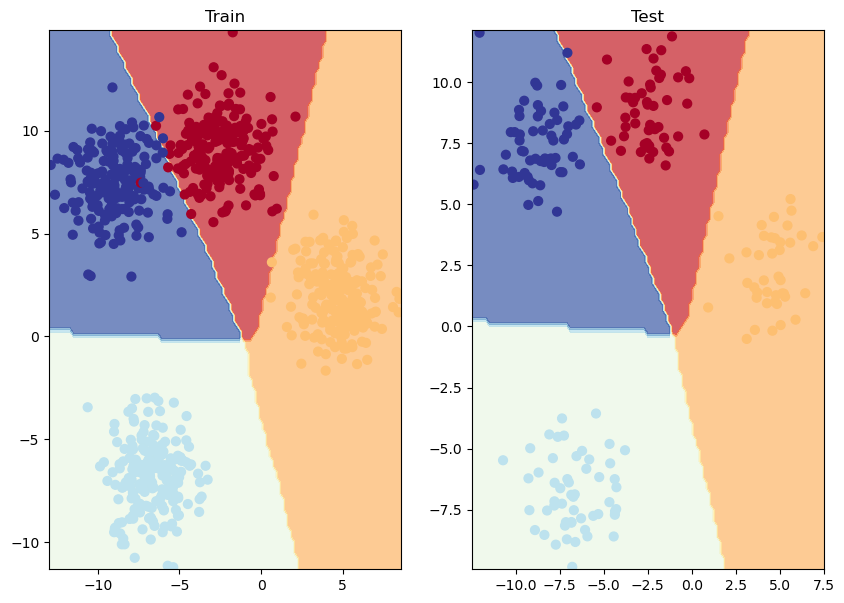

In [75]:
plt.figure(figsize=(10,7))
plt.subplot(1,2,1)
plot_decision_boundary(model_0,X_blob_train,y_blob_train)
plt.title("Train")
plt.subplot(1,2,2)
plot_decision_boundary(model_0,X_blob_test,y_blob_test)
plt.title("Test")


In [76]:
model_0.eval()
with torch.inference_mode():
    y_logits1 = model_0(X_blob_test)
    
y_logits1[:10]

tensor([[  4.2307,  15.9740,  -7.0392,  -9.2354],
        [  3.0289, -23.4665,  -4.1453,  10.1135],
        [ -8.7533,  -3.9055,  10.0058,   0.5083],
        [  2.0910,  10.4249,  -3.6688,  -5.9302],
        [ 11.1544,   2.4227, -15.7212,  -2.8942],
        [  2.8536, -27.7631,  -4.0334,  11.8768],
        [ -7.0357,  -2.8652,   7.8296,   0.3291],
        [ 10.5463,  -4.3981, -14.3994,   0.8808],
        [-11.7483,  -5.6360,  13.7011,   0.8038],
        [ 10.5766,  -1.7012, -14.6376,  -0.5814]])

In [77]:
y_pred_probs1 = torch.softmax(y_logits1,dim=1)
y_pred_probs1[:10]

tensor([[7.9421e-06, 9.9999e-01, 1.0127e-10, 1.1264e-11],
        [8.3717e-04, 2.6063e-15, 6.4138e-07, 9.9916e-01],
        [7.1284e-09, 9.0861e-07, 9.9992e-01, 7.5037e-05],
        [2.4017e-04, 9.9976e-01, 7.5698e-07, 7.8877e-08],
        [9.9984e-01, 1.6136e-04, 2.1283e-12, 7.9198e-07],
        [1.2057e-04, 6.0891e-18, 1.2310e-07, 9.9988e-01],
        [3.4982e-07, 2.2648e-05, 9.9942e-01, 5.5248e-04],
        [9.9994e-01, 3.2337e-07, 1.4661e-11, 6.3428e-05],
        [8.8610e-12, 3.9997e-09, 1.0000e+00, 2.5048e-06],
        [9.9998e-01, 4.6537e-06, 1.1210e-11, 1.4261e-05]])

In [78]:
y_predss1 = torch.argmax(y_pred_probs1,dim=1)
y_predss1[:10]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])

In [79]:
y_blob_test[:10]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])

1) Accuracy : (tp+tn)/(tp+tn+fp+fn) -> torchmetrics.Acuracy()
2) Precision : (tp)/(tp+fp) -> torchmetrics.Precision()
3) Recall : (tp)/(tp+fn) -> torchmetrics.Recall()
4) F1 : (2*precision*recall)/(precision+recall) -> torchmetrics.F1Score()